the solution of the tasks its in the bottom

Ali Jafar Altaweel
2240006456
7MA2

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 1. Unsharp masking

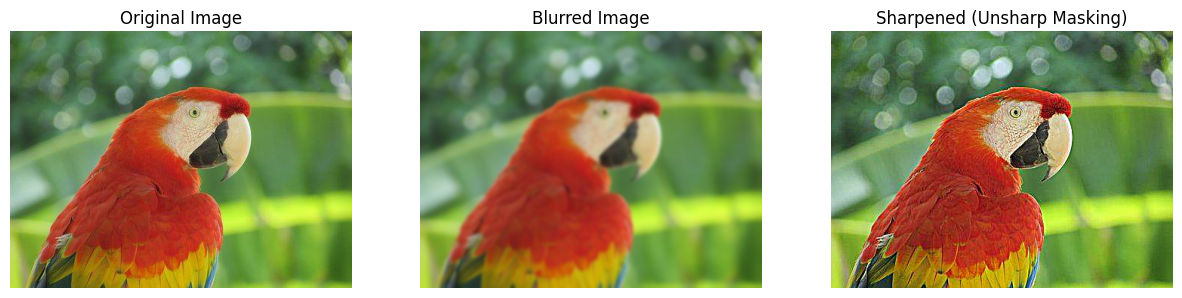

In [2]:
# Read the image
image = cv2.imread('images/Parrot.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB

# Gaussian sigma
sigma=2

#parameter
amount=1.5

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)
# Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(blurred)
ax[1].set_title("Blurred Image")
ax[1].axis("off")

ax[2].imshow(sharpened)
ax[2].set_title("Sharpened (Unsharp Masking)")
ax[2].axis("off")

plt.show()

In [3]:
def sharpness(im):
    """Variance of the Laplacian of the gray image : higher = sharper."""
    im8 = np.clip(im * 255, 0, 255).astype(np.uint8) if im.dtype != np.uint8 else im
    gray = cv2.cvtColor(im8, cv2.COLOR_RGB2GRAY) if im8.ndim == 3 else im8
    return float(cv2.Laplacian(gray, cv2.CV_64F, ksize=1).var())

print("image :", image.shape, image.dtype)
print("sharpness original  :", round(sharpness(image), 1))
print("sharpness blurred   :", round(sharpness(blurred), 1))
print("sharpness sharpened :", round(sharpness(sharpened), 1))

image : (340, 453, 3) uint8
sharpness original  : 442.4
sharpness blurred   : 3.8
sharpness sharpened : 2278.3


mask : min/max = -0.442 0.439


amount = 0.5 -> sharpness =   951.1   clipped values = 0.80%
amount = 1.5 -> sharpness =  2278.3   clipped values = 1.87%


amount = 4   -> sharpness =  6022.4   clipped values = 5.24%


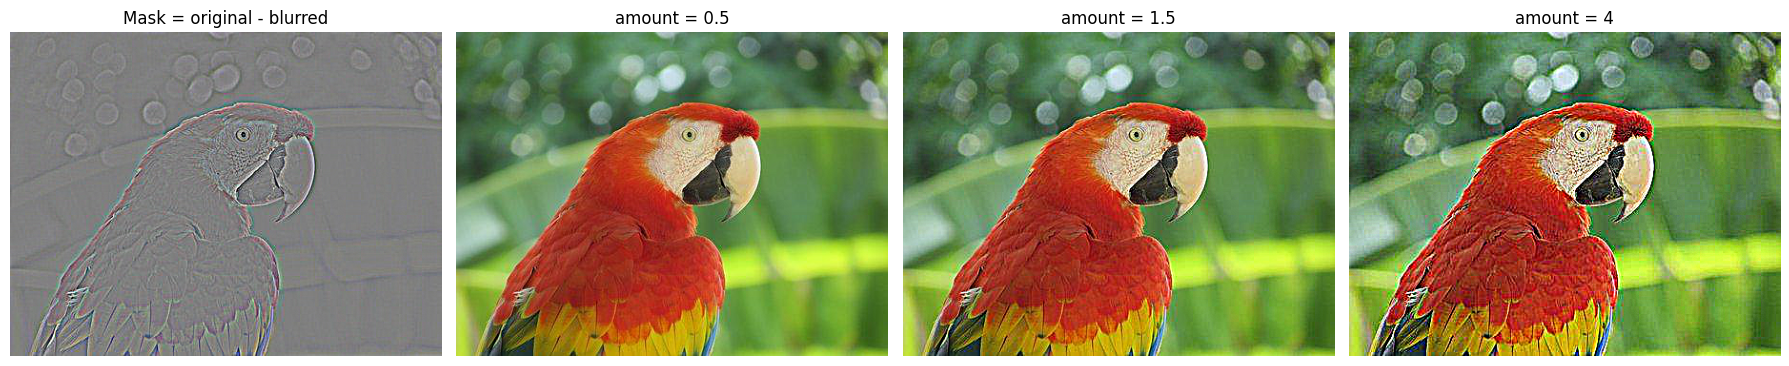

In [4]:
# the mask that is added back, and the effect of the amount parameter
mask = image_float - blurred
print("mask : min/max =", round(float(mask.min()), 3), round(float(mask.max()), 3))

amounts = [0.5, 1.5, 4]
fig, ax = plt.subplots(1, 4, figsize=(18, 4.5))
ax[0].imshow(np.clip(0.5 + 2 * mask, 0, 1))          # shifted to mid gray so negative values are visible
ax[0].set_title("Mask = original - blurred")
ax[0].axis("off")
for k, a in enumerate(amounts):
    s = np.clip(image_float + a * mask, 0, 1)
    clipped = 100 * ((image_float + a * mask < 0) | (image_float + a * mask > 1)).mean()
    print(f"amount = {a:<3} -> sharpness = {sharpness(s):7.1f}   clipped values = {clipped:.2f}%")
    ax[k + 1].imshow(s)
    ax[k + 1].set_title(f"amount = {a}")
    ax[k + 1].axis("off")
plt.tight_layout()
plt.show()

## 2. Student tasks

### Task 1
Convolve an image with a 7x7 box filter, and output the original and smoothed image side by side

### Task 2
Using an image of your choice, apply a 5x5 Gaussian filter to the image, then a 21x21 Gaussian filter, and show the three images side by side.

### Task 3
Using an image of your choice, apply a 3x3 Laplacian filter to sharpen the image. Follow the following steps:
- Read the image
- Convert image to float32
- Use the cv2.Laplacian() function
- Sharpen the image using: np.clip(image_float - laplacian, 0, 1)
- Plot the original image, the resulting image after applying the Laplacian filter, and the sharpened image

### Task 1 Solution – 7x7 box filter

kernel shape : (7, 7)   each weight = 0.02041   sum = 1.0


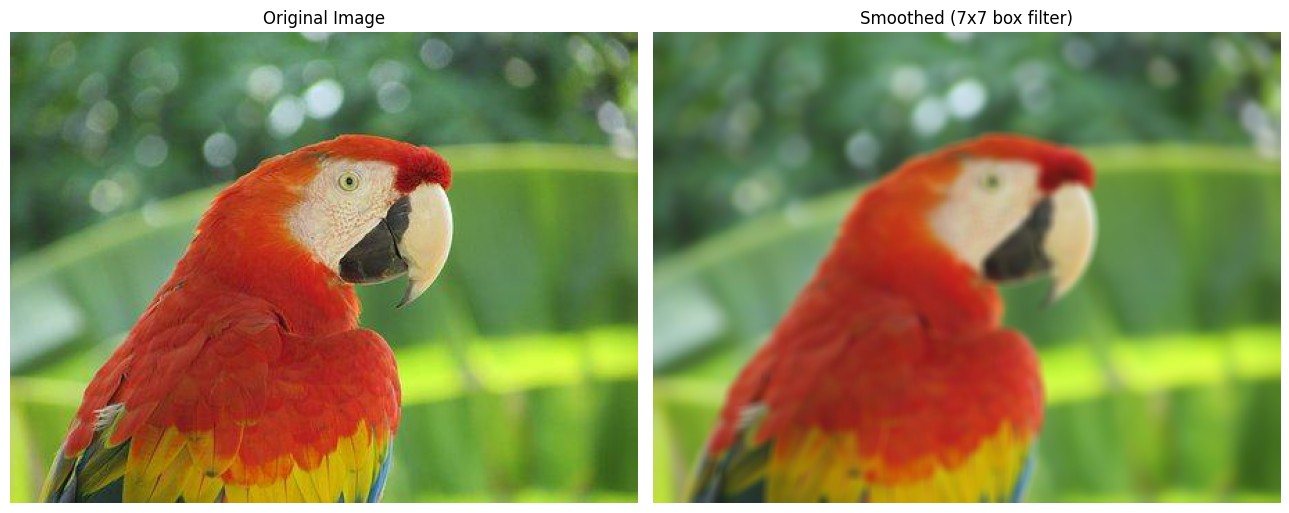

In [5]:
# Read the image
image = cv2.imread('images/Parrot.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB

# 7x7 box filter : 49 equal weights that sum to 1
box_kernel = np.ones((7, 7), np.float32) / 49
print("kernel shape :", box_kernel.shape, "  each weight =", round(float(box_kernel[0, 0]), 5),
      "  sum =", round(float(box_kernel.sum()), 4))

# Convolve the image with the kernel (-1 keeps the depth of the input)
smoothed = cv2.filter2D(image, -1, box_kernel)

# Plot original and smoothed images side by side
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(smoothed)
ax[1].set_title("Smoothed (7x7 box filter)")
ax[1].axis("off")

plt.tight_layout()
plt.show()

largest difference from cv2.blur(image, (7, 7)) : 0 gray level(s)
mean original / smoothed        : 106.1 / 106.1
sharpness original / smoothed   : 442.4 / 4.5


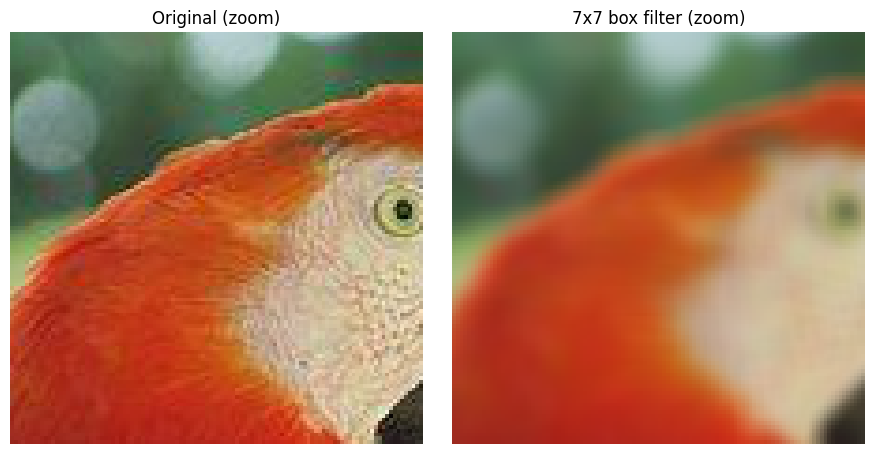

In [6]:
# check : compare with OpenCV's own box filter, and what the smoothing did
diff = np.abs(smoothed.astype(int) - cv2.blur(image, (7, 7)).astype(int))
print("largest difference from cv2.blur(image, (7, 7)) :", int(diff.max()), "gray level(s)")
print("mean original / smoothed        :", round(float(image.mean()), 2), "/", round(float(smoothed.mean()), 2))
print("sharpness original / smoothed   :", round(sharpness(image), 1), "/", round(sharpness(smoothed), 1))

# zoom on the eye to see the loss of detail
r, c, h, w = 60, 140, 110, 110
fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].imshow(image[r:r + h, c:c + w])
ax[0].set_title("Original (zoom)")
ax[0].axis("off")
ax[1].imshow(smoothed[r:r + h, c:c + w])
ax[1].set_title("7x7 box filter (zoom)")
ax[1].axis("off")
plt.tight_layout()
plt.show()

Explanation: a box filter replaces every pixel by the plain average of its 7x7 neighborhood, so all the 49 weights are 1/49 and they sum to 1, which keeps the overall brightness unchanged. The average removes the fine detail of the feathers and spreads every edge over about 7 pixels, so the image looks blurred. The kernel is symmetric, so the correlation that `cv2.filter2D` computes is the same as a convolution.

### Task 2 Solution – 5x5 and 21x21 Gaussian filters

image : (300, 451, 3) uint8


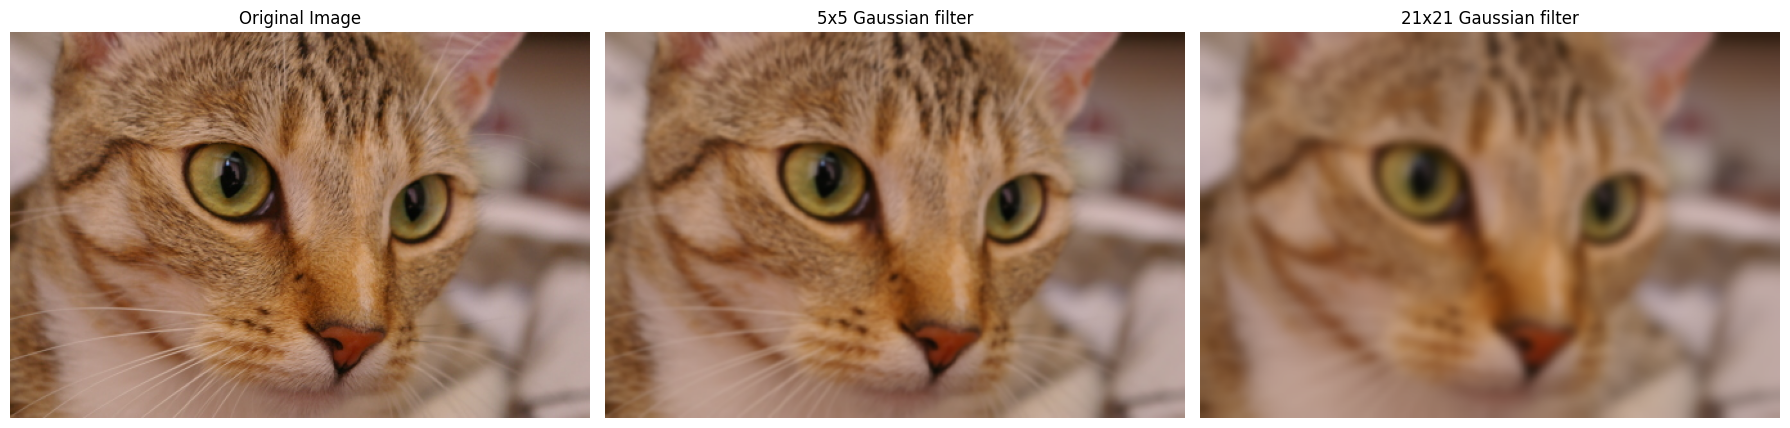

In [7]:
# Read the image (image of my choice : Chelsea the cat)
image = cv2.imread('images/chelsea.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB
print("image :", image.shape, image.dtype)

# sigma = 0 lets OpenCV compute sigma from the kernel size
gauss_5 = cv2.GaussianBlur(image, (5, 5), 0)
gauss_21 = cv2.GaussianBlur(image, (21, 21), 0)

# Plot the three images side by side
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))

ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(gauss_5)
ax[1].set_title("5x5 Gaussian filter")
ax[1].axis("off")

ax[2].imshow(gauss_21)
ax[2].set_title("21x21 Gaussian filter")
ax[2].axis("off")

plt.tight_layout()
plt.show()

 5x5  : sigma = 1.10   sum = 1.0000   center weight = 0.1366   corner weight = 0.005008
21x21 : sigma = 3.50   sum = 1.0000   center weight = 0.0131   corner weight = 0.000004


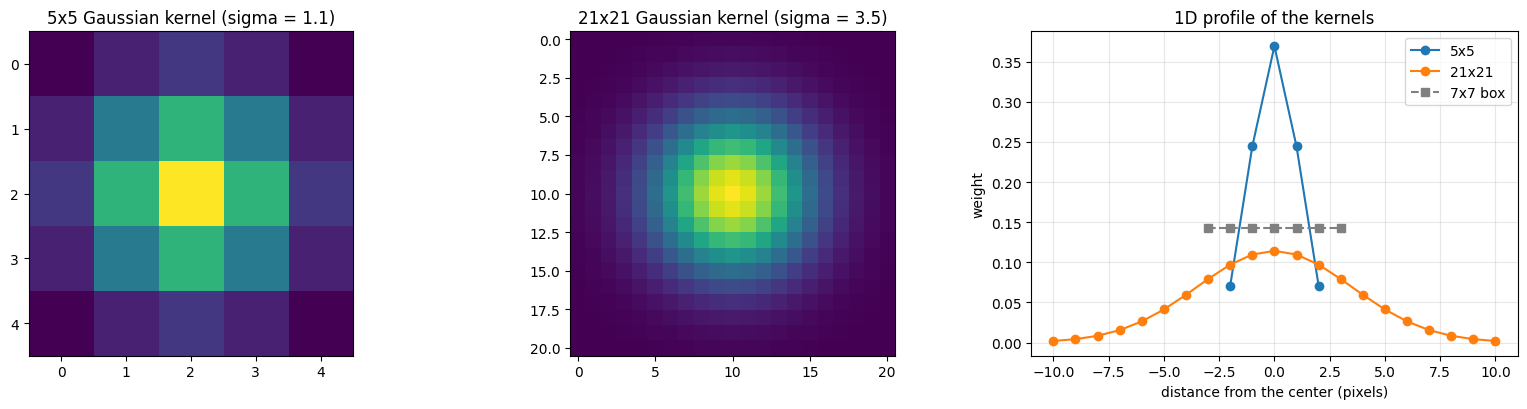


original : mean = 115.31   sharpness =   398.6
     5x5 : mean = 115.31   sharpness =    19.7
   21x21 : mean = 115.30   sharpness =     2.3


In [8]:
# the two kernels : sigma used by OpenCV, and how the weights are distributed
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for k, ksize in enumerate([5, 21]):
    sigma_k = 0.3 * ((ksize - 1) * 0.5 - 1) + 0.8          # OpenCV rule when sigma = 0
    g1 = cv2.getGaussianKernel(ksize, sigma_k)             # 1D kernel
    g2 = g1 @ g1.T                                         # 2D kernel = outer product (separable)
    print(f"{ksize:>2}x{ksize:<2} : sigma = {sigma_k:.2f}   sum = {g2.sum():.4f}   "
          f"center weight = {g2.max():.4f}   corner weight = {g2[0, 0]:.6f}")
    ax[k].imshow(g2, cmap='viridis')
    ax[k].set_title(f"{ksize}x{ksize} Gaussian kernel (sigma = {sigma_k:.1f})")
    ax[2].plot(np.arange(ksize) - ksize // 2, g1.ravel(), 'o-', label=f"{ksize}x{ksize}")
ax[2].plot(np.arange(7) - 3, np.ones(7) / 7, 's--', color='gray', label="7x7 box")
ax[2].set_title("1D profile of the kernels")
ax[2].set_xlabel("distance from the center (pixels)")
ax[2].set_ylabel("weight")
ax[2].legend()
ax[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print()
for name, im in [("original", image), ("5x5", gauss_5), ("21x21", gauss_21)]:
    print(f"{name:>8} : mean = {im.mean():6.2f}   sharpness = {sharpness(im):7.1f}")

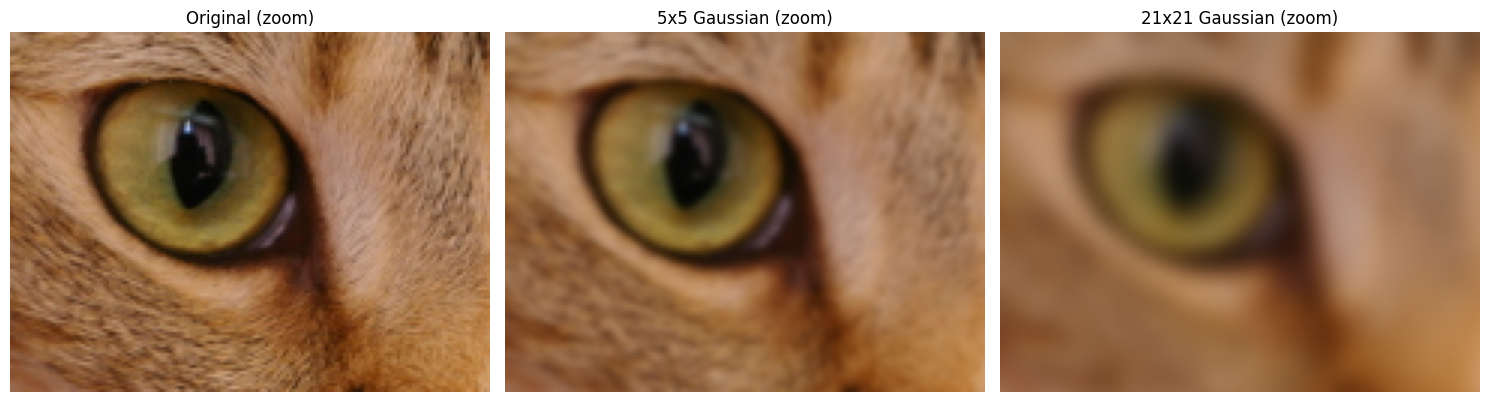

In [9]:
# zoom on the eye and the fur around it
r, c, h, w = 70, 110, 120, 160
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, (im, t) in zip(ax, [(image, "Original (zoom)"), (gauss_5, "5x5 Gaussian (zoom)"),
                           (gauss_21, "21x21 Gaussian (zoom)")]):
    a.imshow(im[r:r + h, c:c + w])
    a.set_title(t)
    a.axis("off")
plt.tight_layout()
plt.show()

Explanation: in a Gaussian filter the weights follow a bell curve, so the pixels near the center count more than the far ones. With sigma set to 0, OpenCV chooses it from the kernel size, 1.1 for the 5x5 kernel and 3.5 for the 21x21 kernel. The 5x5 filter only softens the fur and removes the finest detail, while the 21x21 filter averages over a much larger area and removes the texture of the fur completely, leaving only the large shapes.

### Task 3 Solution – Sharpening with a 3x3 Laplacian filter

image : (512, 512) uint8  min/max = 0 255
laplacian : float32  min/max = -4.353 3.757


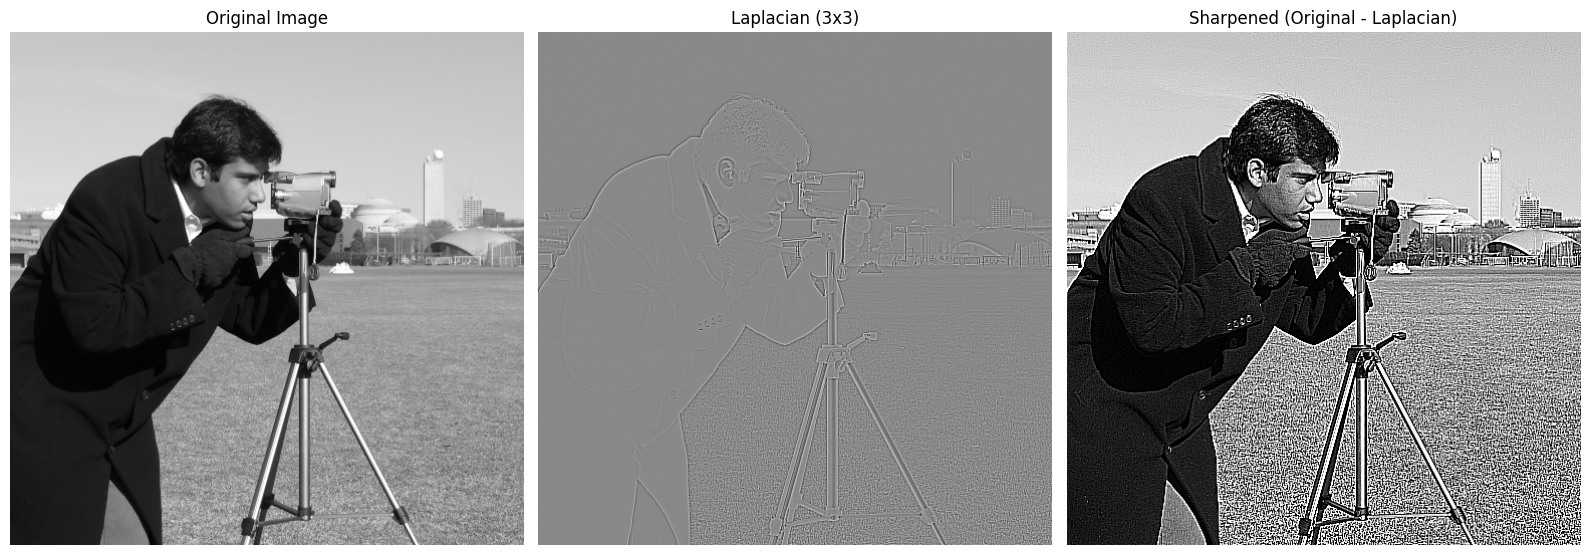

In [10]:
# Read the image (image of my choice : the cameraman, a grayscale image)
image = cv2.imread('images/camera.png', cv2.IMREAD_GRAYSCALE)
print("image :", image.shape, image.dtype, " min/max =", image.min(), image.max())

# Convert image to float32
image_float = image.astype(np.float32) / 255.0

# Apply the 3x3 Laplacian filter
laplacian = cv2.Laplacian(image_float, cv2.CV_32F, ksize=3)
print("laplacian :", laplacian.dtype, " min/max =", round(float(laplacian.min()), 3), round(float(laplacian.max()), 3))

# Sharpen the image
sharpened = np.clip(image_float - laplacian, 0, 1)

# Plot the original image, the Laplacian, and the sharpened image
fig, ax = plt.subplots(1, 3, figsize=(16, 5.6))

ax[0].imshow(image, cmap='gray', vmin=0, vmax=255)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(laplacian, cmap='gray')
ax[1].set_title("Laplacian (3x3)")
ax[1].axis("off")

ax[2].imshow(sharpened, cmap='gray', vmin=0, vmax=1)
ax[2].set_title("Sharpened (Original - Laplacian)")
ax[2].axis("off")

plt.tight_layout()
plt.show()

In [11]:
# the kernel that cv2.Laplacian really uses : filter a single white pixel (impulse)
impulse = np.zeros((5, 5), np.float32)
impulse[2, 2] = 1
print("kernel for ksize = 3 :")
print(cv2.Laplacian(impulse, cv2.CV_32F, ksize=3)[1:4, 1:4].astype(int))
print("kernel for ksize = 1 (the classic 4-neighbor Laplacian) :")
print(cv2.Laplacian(impulse, cv2.CV_32F, ksize=1)[1:4, 1:4].astype(int))

# numeric check of the result
print()
print("mean of the laplacian             :", round(float(laplacian.mean()), 5))
print("mean original / sharpened         :", round(float(image_float.mean()), 4), "/", round(float(sharpened.mean()), 4))
print("std  original / sharpened         :", round(float(image_float.std()), 4), "/", round(float(sharpened.std()), 4))
print("sharpness original / sharpened    :", round(sharpness(image), 1), "/", round(sharpness(sharpened), 1))
unclipped = image_float - laplacian
print("values clipped to 0 or 1          :", f"{100 * ((unclipped < 0) | (unclipped > 1)).mean():.2f}%")

kernel for ksize = 3 :
[[ 2  0  2]
 [ 0 -8  0]
 [ 2  0  2]]
kernel for ksize = 1 (the classic 4-neighbor Laplacian) :
[[ 0  1  0]
 [ 1 -4  1]
 [ 0  1  0]]

mean of the laplacian             : 4e-05
mean original / sharpened         : 0.5061 / 0.4988
std  original / sharpened         : 0.2888 / 0.3565
sharpness original / sharpened    : 1133.2 / 40577.5
values clipped to 0 or 1          : 17.67%


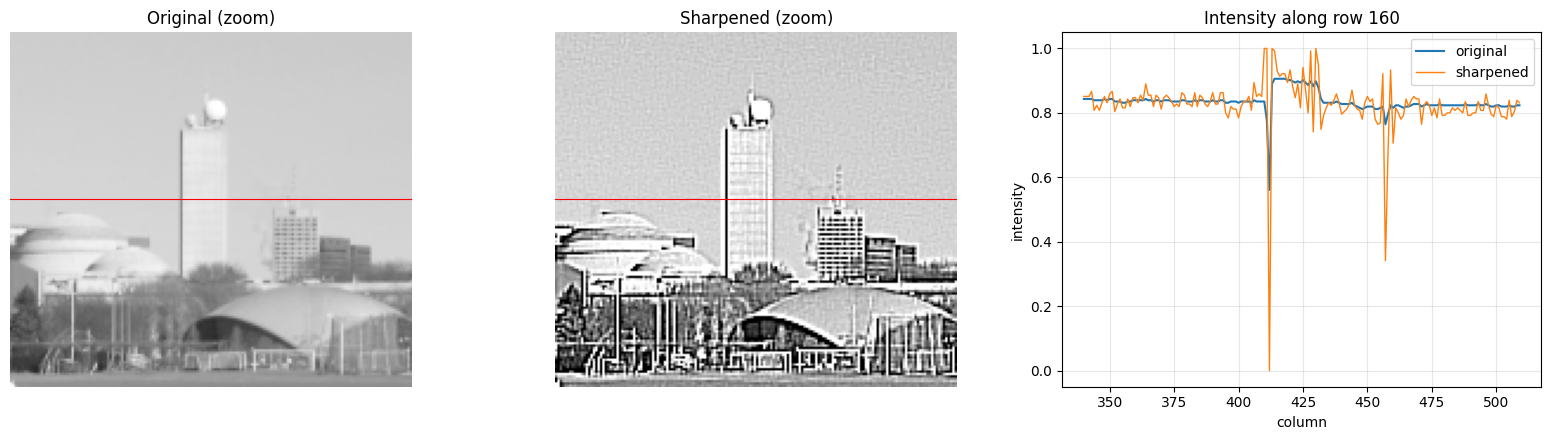

In [12]:
# zoom on the buildings, and one row of pixels across the tower
r, c, h, w = 90, 340, 150, 170
row = r + 70
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].imshow(image_float[r:r + h, c:c + w], cmap='gray', vmin=0, vmax=1)
ax[0].axhline(row - r, color='r', lw=0.8)
ax[0].set_title("Original (zoom)")
ax[0].axis("off")
ax[1].imshow(sharpened[r:r + h, c:c + w], cmap='gray', vmin=0, vmax=1)
ax[1].axhline(row - r, color='r', lw=0.8)
ax[1].set_title("Sharpened (zoom)")
ax[1].axis("off")
ax[2].plot(np.arange(c, c + w), image_float[row, c:c + w], label="original")
ax[2].plot(np.arange(c, c + w), sharpened[row, c:c + w], label="sharpened", lw=1)
ax[2].set_title(f"Intensity along row {row}")
ax[2].set_xlabel("column")
ax[2].set_ylabel("intensity")
ax[2].legend()
ax[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

Explanation: the Laplacian is a second derivative, so it is zero in the flat regions and gives strong positive and negative values on the two sides of every edge, which is why its image is gray with only the edges visible. The center of the OpenCV kernel is negative, so the Laplacian has to be subtracted from the image to sharpen it: the dark side of an edge becomes darker and the bright side brighter. The weights of the kernel sum to 0, so the average brightness of the image stays almost the same and only the local contrast increases.